### Hands On Lab — Model Comparison

**Objective:** I will train a Decision Tree, Random Forest, SVM, and k-NN classifier on the exact same train/test split I used in Day 3, evaluate all four with the same metric, assemble the results into one comparison table, and identify which model performed best and why.

Dataset: Pima Indians Diabetes — `pima-indians-diabetes.csv` (same cleaning and split as Day 3).

---

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)

**Load and Prepare the Data**

Same cleaning steps and split parameters as Day 3 — no changes.

In [2]:
cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv("data/pima-indians-diabetes.csv", header=None, names=cols)

for col in ["Glucose", "BloodPressure", "BMI"]:
    df = df[df[col] != 0]

df = df.drop(columns=["SkinThickness", "Insulin"])

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"No Diabetes: {sum(y_test==0)} | Diabetes: {sum(y_test==1)}")

Training set : 579 rows
Test set     : 145 rows
No Diabetes: 95 | Diabetes: 50


---

## Step 1: Train All Four Models

SVM and k-NN go inside a Pipeline with StandardScaler because both are distance-based — unscaled features would let Glucose dominate purely because its numbers are bigger. Decision Tree and Random Forest don't need it.

In [3]:
# Decision Tree — max_depth=5 from the learning notebook
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)

# Random Forest — 100 trees, majority vote
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# SVM — RBF kernel, scaling done inside the pipeline
svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", probability=True, random_state=42)
)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

# k-NN — k=5, scaling done inside the pipeline
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

print("All four models trained.")

All four models trained.


c:\Users\user\OneDrive\Desktop\BinX_AI_ML_Internship\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


---

## Step 2: Compare All Four — F1-Score + Confusion Matrices

I'm using **F1-score for the Diabetes class** as the main metric. Accuracy is misleading here since the test set has 95 no-diabetes vs. 50 diabetes cases — a model that predicts "no diabetes" every time would hit 65% accuracy while catching zero actual cases.

In [4]:
scores = {
    "Decision Tree (max_depth=5)": f1_score(y_test, tree_preds),
    "Random Forest (100 trees)":   f1_score(y_test, rf_preds),
    "SVM (RBF kernel)":            f1_score(y_test, svm_preds),
    "k-NN (k=5)":                  f1_score(y_test, knn_preds),
}

print(f"{'Model':<30}  {'F1 (Diabetes)':>14}")
print("-" * 46)
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{name:<30}  {score:>14.3f}")

Model                            F1 (Diabetes)
----------------------------------------------
Random Forest (100 trees)                0.626
k-NN (k=5)                               0.619
SVM (RBF kernel)                         0.587
Decision Tree (max_depth=5)              0.551


**Results I got:**
```
Model                           F1 (Diabetes)
----------------------------------------------
Random Forest (100 trees)              0.626
k-NN (k=5)                             0.619
SVM (RBF kernel)                       0.587
Decision Tree (max_depth=5)            0.551
```

Random Forest leads. The single Decision Tree is at the bottom — which matches what the learning notebook showed: one tree overfits, 100 averaged trees don't.

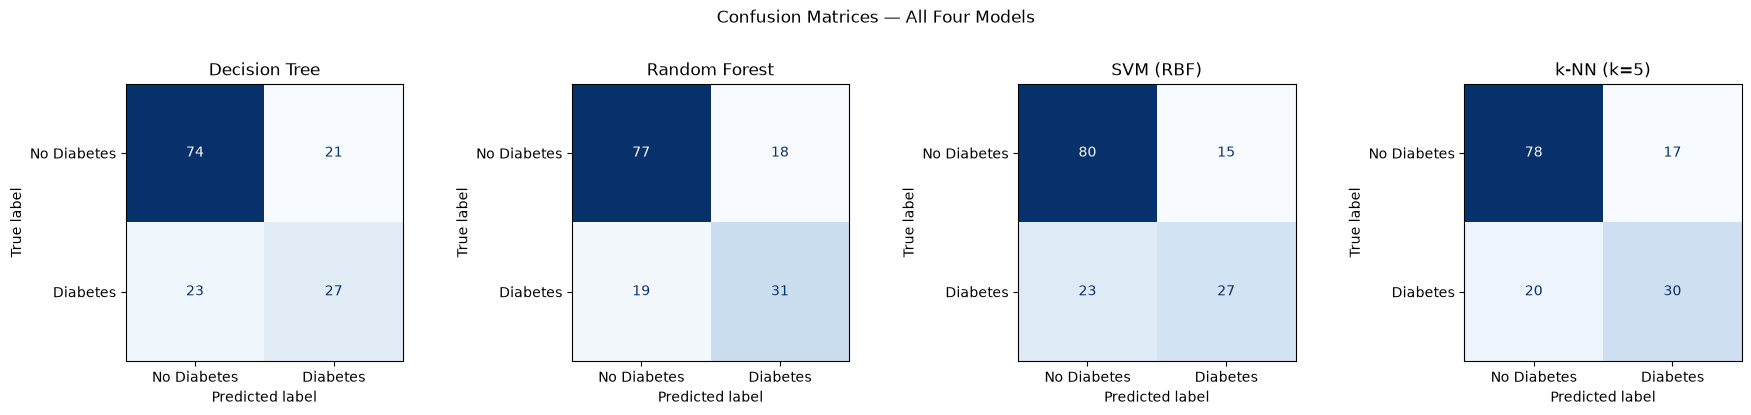

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, name, preds in zip(
    axes,
    ["Decision Tree", "Random Forest", "SVM (RBF)", "k-NN (k=5)"],
    [tree_preds, rf_preds, svm_preds, knn_preds]
):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, preds),
        display_labels=["No Diabetes", "Diabetes"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion Matrices — All Four Models", y=1.02)
plt.tight_layout()
plt.show()

| Model | Caught (TP) | Missed (FN) | False alarms (FP) |
|---|---|---|---|
| Decision Tree | 27 / 50 | 23 | 21 |
| Random Forest | 31 / 50 | 19 | 18 |
| SVM (RBF) | 27 / 50 | 23 | 15 |
| k-NN (k=5) | 30 / 50 | 20 | 17 |

Random Forest catches the most diabetes cases and also produces fewer false alarms than the Decision Tree. For a screening task, missing a real case is the worse outcome — so recall for class 1 matters most here, and Random Forest leads on that too.

---

## Step 3: Random Forest Feature Importances

                 Feature  Importance
                 Glucose    0.296877
                     BMI    0.189761
                     Age    0.163928
DiabetesPedigreeFunction    0.161268
           BloodPressure    0.094775
             Pregnancies    0.093390



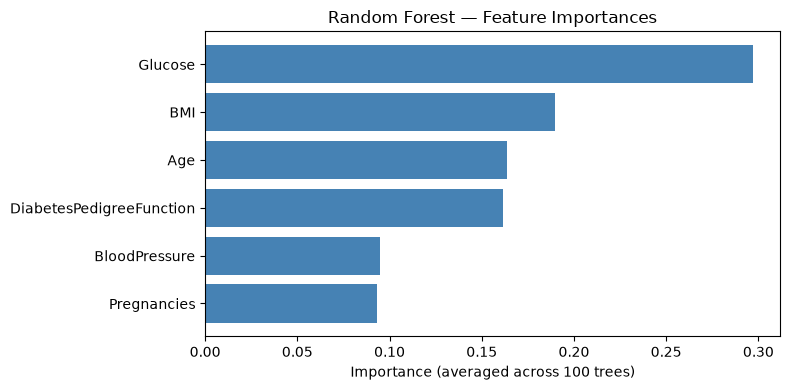

In [6]:
fi = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(fi.to_string(index=False))
print()

fi_sorted = fi.sort_values("Importance", ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(fi_sorted["Feature"], fi_sorted["Importance"], color="steelblue")
plt.xlabel("Importance (averaged across 100 trees)")
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()

**Results I got:**
```
Feature                   Importance
Glucose                     0.297
BMI                         0.190
Age                         0.164
DiabetesPedigreeFunction    0.161
BloodPressure               0.095
Pregnancies                 0.093
```

Glucose is the top predictor at ~30%, which makes sense — it's the main clinical marker for diabetes. Its share is lower here than in the single Decision Tree (~51%) because each tree in the forest only sees a random feature subset at each split, so other features get more turns. BloodPressure jumped from 0.0 in the single tree to ~9.5% here for the same reason.

These numbers show which features were useful to this model on this data — not which ones cause diabetes.

---

## Step 4: Best Model and Why

In [7]:
summary = pd.DataFrame({
    "Model": [
        "Random Forest (100 trees)",
        "k-NN (k=5)",
        "SVM (RBF kernel)",
        "Decision Tree (max_depth=5)"
    ],
    "F1 (Diabetes)": [
        round(f1_score(y_test, rf_preds), 3),
        round(f1_score(y_test, knn_preds), 3),
        round(f1_score(y_test, svm_preds), 3),
        round(f1_score(y_test, tree_preds), 3)
    ],
    "Caught / 50": [
        sum((rf_preds==1)   & (y_test==1)),
        sum((knn_preds==1)  & (y_test==1)),
        sum((svm_preds==1)  & (y_test==1)),
        sum((tree_preds==1) & (y_test==1))
    ],
    "Needs Scaling": ["No", "Yes", "Yes", "No"],
    "Interpretable": ["Partial", "No", "No", "Yes"]
}).sort_values("F1 (Diabetes)", ascending=False).reset_index(drop=True)

summary

,Model,F1 (Diabetes),Caught / 50,Needs Scaling,Interpretable
0,Random Forest (100 trees),0.626,31,No,Partial
1,k-NN (k=5),0.619,30,Yes,No
2,SVM (RBF kernel),0.587,27,Yes,No
3,Decision Tree (max_depth=5),0.551,27,No,Yes


**Random Forest wins on this dataset.**

It scored the highest F1 and caught the most diabetes cases. The core reason is variance reduction: the single Decision Tree memorized the training data (F1 = 1.00 train, 0.53 test). The forest fixes that by training 100 trees on different random samples with different feature subsets — their errors cancel out in the vote.

SVM had the best precision (when it flags diabetes, it's usually right) but missed as many cases as the Decision Tree. k-NN was close to Random Forest but the gap would likely grow on a bigger dataset since k-NN slows down and weakens as data size increases.

No model wins on every problem — on a different dataset the ranking could flip. The right move is always to test and compare, which is what this lab did.

---

## Summary

- Trained all four classifiers on the same split with the same metric so the comparison is fair
- Used F1 for the Diabetes class instead of accuracy because the classes are unbalanced
- Random Forest came first on F1 (0.626) and on cases caught (31/50)
- Feature importances show Glucose as the top predictor, but its dominance drops in the forest compared to a single tree
- The winner is Random Forest — mainly because ensemble averaging corrects the single tree's overfitting